## K-Means Clustering Analysis with Generated Data

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score

plt.style.use('seaborn-v0_8')

## Generate Sample Data

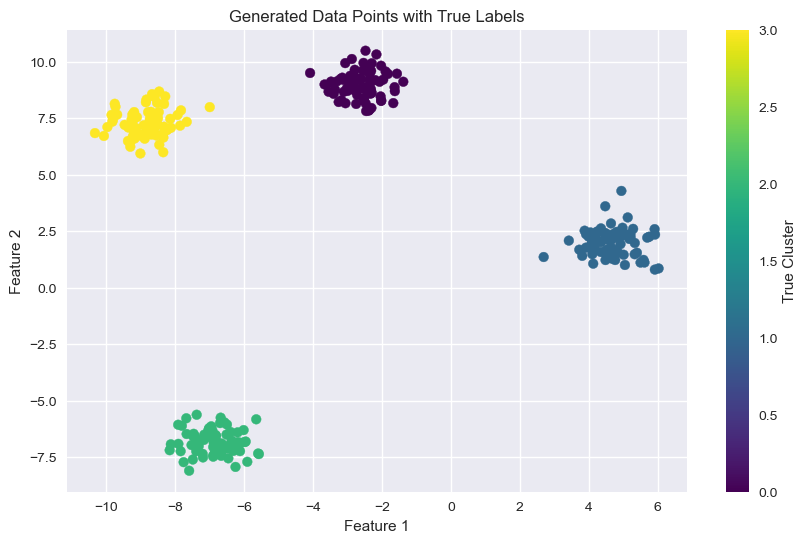

In [3]:
X, y_true = make_blobs(n_samples=300, centers=4, 
                      cluster_std=0.6, random_state=42)

plt.figure(figsize=(10, 6))
plt.scatter(X[:, 0], X[:, 1], c=y_true, cmap='viridis')
plt.title('Generated Data Points with True Labels')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.colorbar(label='True Cluster')
plt.show()

## Find Optimal K using Elbow Method

c:\Users\BasitSachinwala\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] The system cannot find the file specified
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "c:\Users\BasitSachinwala\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
        "wmic CPU Get NumberOfCores /Format:csv".split(),
        capture_output=True,
        text=True,
    )
  File "c:\Users\BasitSachinwala\anaconda3\Lib\subprocess.py", line 554, in run
    with Popen(*popenargs, **kwargs) as process:
         ~~~~~^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\BasitSachinwala\anaconda3\Lib\subprocess.py", line 1039, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
 

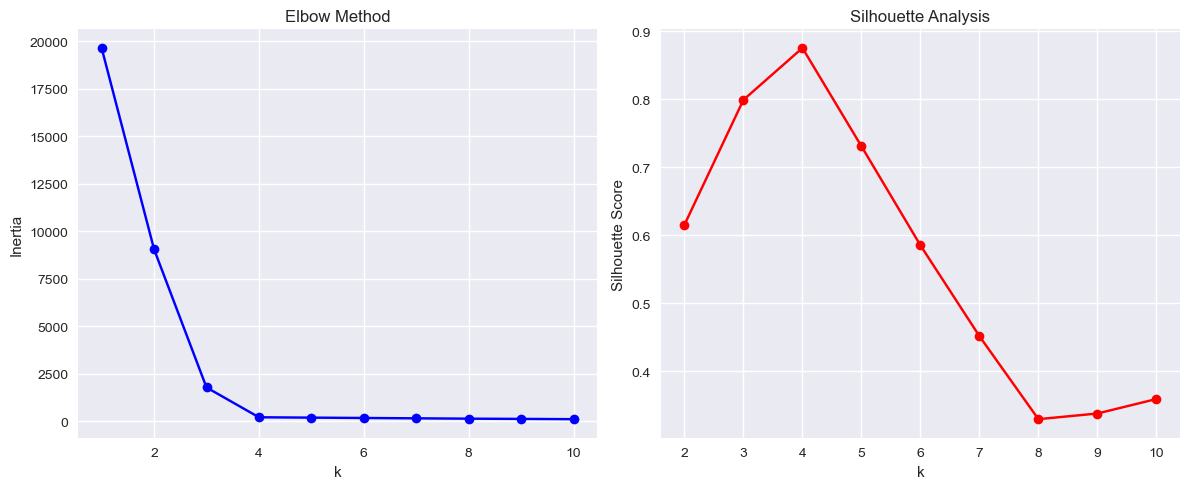

In [4]:
inertias = []
silhouette_scores = []
k_range = range(1, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X)
    inertias.append(kmeans.inertia_)
    if k > 1:  # Silhouette score requires at least 2 clusters
        silhouette_scores.append(silhouette_score(X, kmeans.labels_))

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(k_range, inertias, 'bo-')
plt.xlabel('k')
plt.ylabel('Inertia')
plt.title('Elbow Method')

plt.subplot(1, 2, 2)
plt.plot(list(k_range)[1:], silhouette_scores, 'ro-')
plt.xlabel('k')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Analysis')
plt.tight_layout()
plt.show()

## Train K-Means Model with Optimal K

c:\Users\BasitSachinwala\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


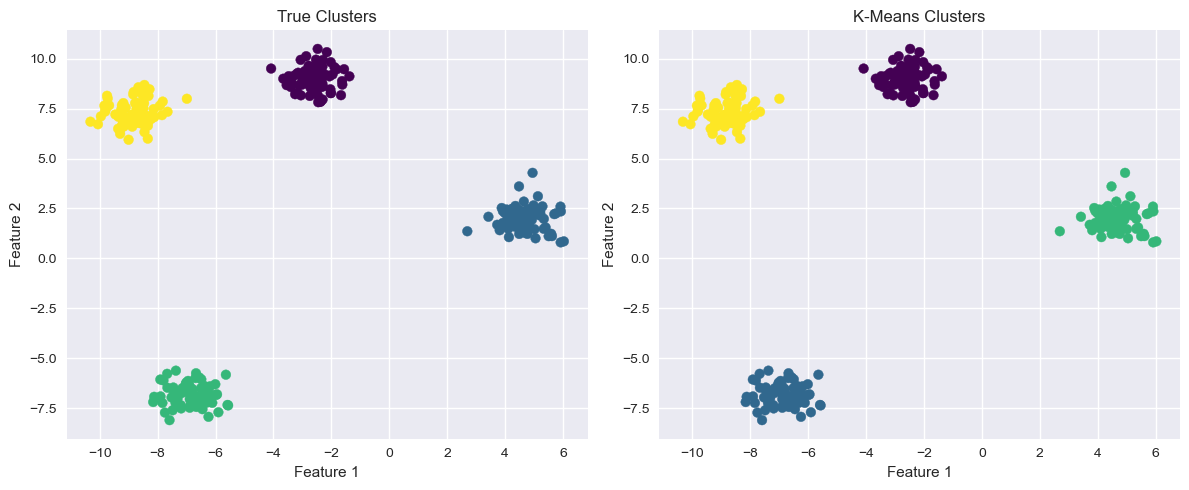

In [5]:
optimal_k = 4  # Based on elbow method and silhouette analysis
kmeans = KMeans(n_clusters=optimal_k, random_state=42)
y_pred = kmeans.fit_predict(X)

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.scatter(X[:, 0], X[:, 1], c=y_true, cmap='viridis')
plt.title('True Clusters')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')

plt.subplot(1, 2, 2)
plt.scatter(X[:, 0], X[:, 1], c=y_pred, cmap='viridis')
plt.title('K-Means Clusters')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.tight_layout()
plt.show()

## Model Evaluation

Clustering Performance Metrics:
------------------------------
Silhouette Score: 0.876


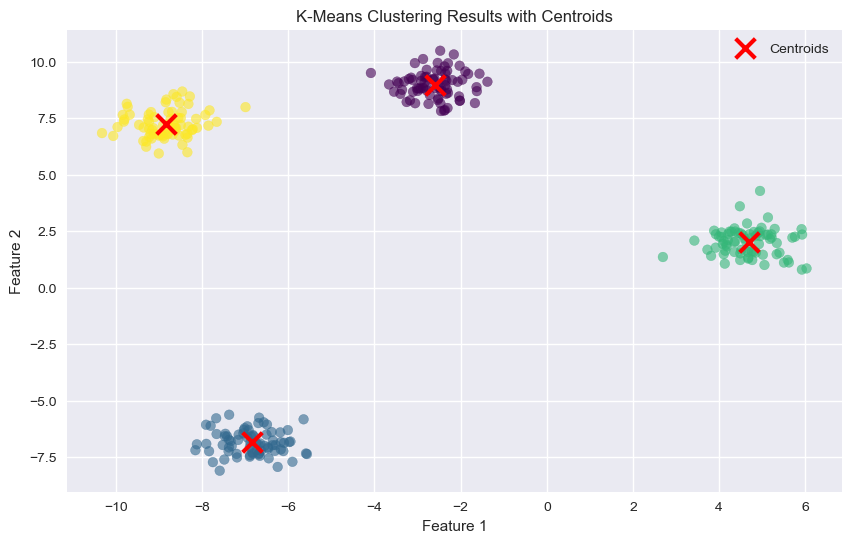

In [6]:
print("Clustering Performance Metrics:")
print("-" * 30)
print(f"Silhouette Score: {silhouette_score(X, y_pred):.3f}")
#print(f"Calinski-Harabasz Score: {calinski_harabasz_score(X, y_pred):.3f}")
#print(f"Davies-Bouldin Score: {davies_bouldin_score(X, y_pred):.3f}")

centers = kmeans.cluster_centers_
plt.figure(figsize=(10, 6))
plt.scatter(X[:, 0], X[:, 1], c=y_pred, cmap='viridis', alpha=0.6)
plt.scatter(centers[:, 0], centers[:, 1], c='red', marker='x', s=200, linewidths=3, label='Centroids')
plt.title('K-Means Clustering Results with Centroids')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend()
plt.show()

cluster_sizes = pd.Series(y_pred).value_counts().sort_index()
plt.figure(figsize=(10, 5))
cluster_sizes.plot(kind='bar')
plt.title('Number of Points in Each Cluster')
plt.xlabel('Cluster')
plt.ylabel('Number of Points')
plt.show()

print("\nCluster Sizes:")
print("-" * 30)
for cluster, size in enumerate(cluster_sizes):
    print(f"Cluster {cluster}: {size} points")

# Calculate cluster statistics
cluster_df = pd.DataFrame(X, columns=['Feature 1', 'Feature 2'])
cluster_df['Cluster'] = y_pred

print("\nCluster Statistics:")
print("-" * 30)
for cluster in range(optimal_k):
    cluster_data = cluster_df[cluster_df['Cluster'] == cluster]
    print(f"\nCluster {cluster}:")
    print(cluster_data.describe().round(2))